In [1]:
import numpy as np
import xarray as xr
import pandas as pd
import time

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import calendar
import matplotlib.patches as mpatches
import seaborn as sns
import cartopy.crs as ccrs

from pylab import rcParams
rcParams['axes.labelweight'] = 'bold'
rcParams['axes.labelsize'] = 'x-large'
rcParams['axes.titlesize'] = 'xx-large'
rcParams['axes.titleweight'] = 'bold'


In [2]:
def decode_time(filepath):
    ds = xr.open_dataset(filepath, decode_times=False)
    units, reference_date = ds.time.attrs['units'].split('since')
    ds['time'] = pd.date_range(start=reference_date, periods=ds.sizes['time'], freq='MS')
    return ds


In [3]:
#load the masks
fp = '/data/jmex/masks/RECCAP2_region_masks_all.nc'
masks = xr.open_dataset(fp)


In [4]:
fp = '/data/jmex/ERA5/monthly/rad_forcing/era5_toa_global.nc'
ds = xr.open_dataset(fp).rename({'latitude': 'lat', 'longitude': 'lon', 'valid_time': 'time'}).drop_vars('expver')

#interpolate to masks grid
ds = ds.interp(lat=masks.lat, lon=masks.lon)


In [5]:
fp = '/data/jmex/ERA5/monthly/rad_forcing/era5_lcc_global.nc'
ds = xr.open_dataset(fp).rename({'latitude': 'lat', 'longitude': 'lon', 'valid_time': 'time'}).drop_vars('expver')

#interpolate to masks grid
ds = ds.interp(lat=masks.lat, lon=masks.lon)


In [6]:
lcc = ds.where(ds.time.dt.month.isin(np.arange(4,9)), drop = True).groupby('time.year').mean('time')
clim = lcc.sel(year = slice(1991, 2020)).mean('year')
lcc= lcc - clim
dlcc = lcc - lcc.shift(year = 1)


In [6]:
weights = np.cos(np.deg2rad(ds.lat))

In [7]:
dlcc.weighted(weights).mean(['lat', 'lon']).lcc.plot(marker = 'o')
plt.grid()

NameError: name 'weights' is not defined

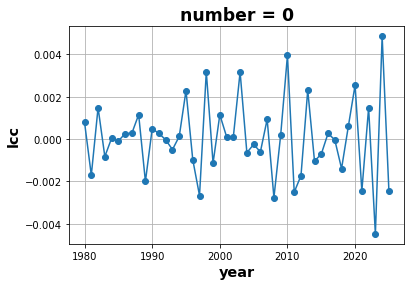

In [ ]:
area_weight = masks.open_ocean.isin([2,3]).where((masks.lat <= 20) & (masks.lat >= -20)).weighted(weights).sum(('lat','lon'))/masks.seamask.isin([0,1]).weighted(weights).sum(('lat','lon'))

(dlcc.where(masks.open_ocean.isin([2,3]) & (masks.lat <= 20) & (masks.lat >= -20), drop=True).weighted(weights).mean(['lat', 'lon'])* area_weight).lcc.plot(marker = 'o')
plt.grid()

In [ ]:
dlcc.weighted(weights).mean(['lat', 'lon'])

<xarray.Dataset>
Dimensions:  (year: 47)
Coordinates:
    number   int64 0
  * year     (year) int64 1979 1980 1981 1982 1983 ... 2021 2022 2023 2024 2025
Data variables:
    lcc      (year) float64 nan 0.003494 -0.002301 ... 0.00938 -0.003336

In [ ]:
4.98e-3/.0098

0.5081632653061224

In [ ]:
#ds = ds.where((ds.lat>20) | (ds.lat<-20), drop=True)
#ds = ds.where(masks.seamask == 1, drop=True)

In [7]:
#convert J/m2 to W/m2
ds = ds / (24*60*60)

In [8]:
weights = np.cos(np.deg2rad(ds.lat))

#extract variable toa_net_all_mon
ds['tnet'] = ds.tsr + ds.ttr
toa = ds.tnet
#compute anomaly
toa = toa.groupby('time.month') - toa.groupby('time.month').mean('time')

#exract april-september
toa = toa.where((toa['time.month'] >= 4) & (toa['time.month'] <= 9), drop=True).groupby('time.year').mean('time')

#compute difference
dtoa = toa - toa.shift(year=1)

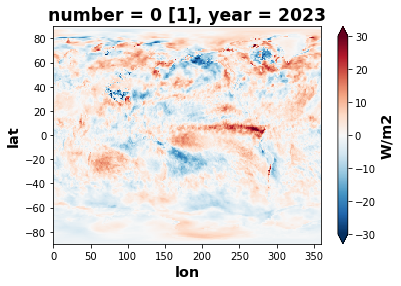

In [9]:
dtoa.sel(year = 2023).plot(vmin = -30, vmax=30, cmap='RdBu_r', cbar_kwargs={'label': 'W/m2'})

In [10]:
bs = dtoa.where(dtoa.year.isin([1982, 1987, 1991, 1997, 2009, 2015]), drop=True)

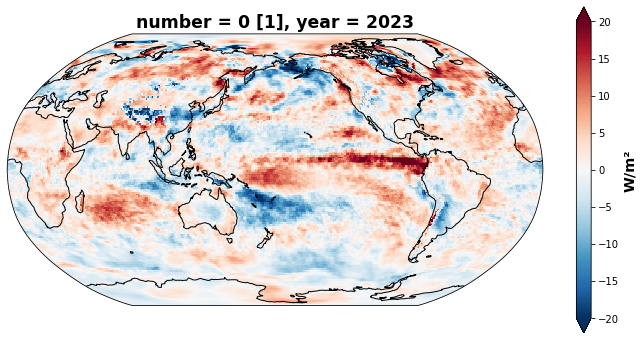

In [11]:
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.Robinson(central_longitude=180)}, figsize=(12,6))
a = dtoa.sel(year=2023)
a.plot.pcolormesh(ax=ax, transform=ccrs.PlateCarree(), cmap='RdBu_r', vmin = -20, vmax = 20, cbar_kwargs={'label': 'W/m²'})
ax.coastlines()


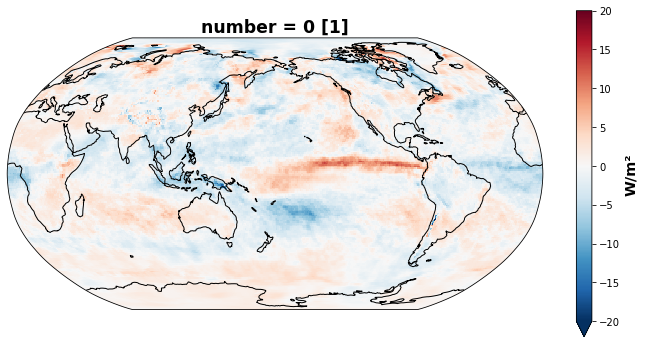

In [12]:
l= [1982, 1987, 1991, 1997, 2009, 2015]
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.Robinson(central_longitude=180)}, figsize=(12,6))
k = dtoa.where(dtoa.year.isin(l), drop=True).mean('year')
k.plot.pcolormesh(ax=ax, transform=ccrs.PlateCarree(), cmap='RdBu_r', vmin=-20, vmax=20, cbar_kwargs={'label': 'W/m²'})
ax.coastlines()
plt.show()

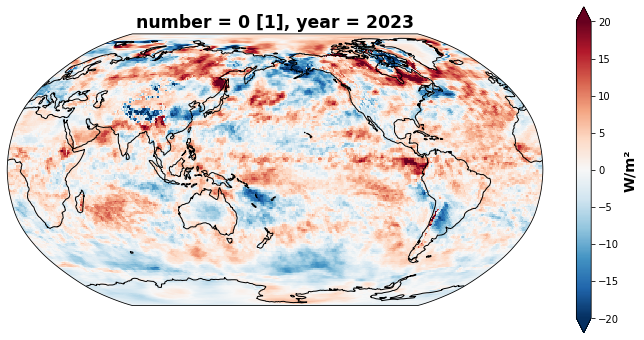

In [13]:
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.Robinson(central_longitude=180)}, figsize=(12,6))
(a-k).plot.pcolormesh(ax=ax, transform=ccrs.PlateCarree(), cmap='RdBu_r', vmin=-20, vmax=20, cbar_kwargs={'label': 'W/m²'})
ax.coastlines()
plt.show()

In [14]:
trop_indopac_mask = masks.open_ocean.isin([2,3]) & (masks.lat <= 20) & (masks.lat >= -20)
dn_mean = dtoa.where(trop_indopac_mask).weighted(weights).mean(('lat', 'lon'))


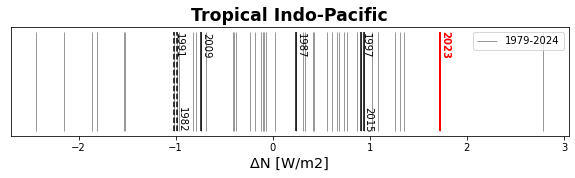

In [15]:
composite_years = [1982, 1987, 1991, 1997,  2015, 2009]
dn_composite = dn_mean.where(dn_mean.year.isin([composite_years]), drop = True)

# Create a figure
fig, ax = plt.subplots(figsize=(10, 2))

# Plot all years in grey
ax.vlines(dn_mean, ymin=0, ymax=1, color='grey', linewidth=0.8, label = '1979-2024')

# Plot composite years in black
ax.vlines(dn_mean.sel(year = 1982), ymin=0, ymax=1, color='black', linewidth=1.5, linestyle = '--')
ax.vlines(dn_mean.sel(year = 1987), ymin=0, ymax=1, color='black', linewidth=1.5)
ax.vlines(dn_mean.sel(year = 1991), ymin=0, ymax=1, color='black', linewidth=1.5, linestyle = '--')
ax.vlines(dn_mean.sel(year = 1997), ymin=0, ymax=1, color='black', linewidth=1.5)
ax.vlines(dn_mean.sel(year = 2009), ymin=0, ymax=1, color='black', linewidth=1.5)
ax.vlines(dn_mean.sel(year = 2015), ymin=0, ymax=1, color='black', linewidth=1.5)





for y in dn_composite.year.values: 
    x = dn_mean.sel(year = y)
    if y in [1991, 1987, 1997, 2009]:
        ax.annotate(y, (x, 0.75), rotation = 270)
    else: 
        ax.annotate(y, (x, 0.), rotation = 270)
        

x = dn_mean.sel(year= 2023)
ax.vlines(x, ymin=0, ymax=1, color='red', linewidth=2)
ax.annotate(2023,  (x, 0.75), rotation = 270, fontweight = 'bold', color = 'r')


# Formatting
#ax.set_xticks(years[::5])  # Show every 5th year for readability
#ax.set_xlim(min(years) - 1, max(years) + 1)
ax.set_yticks([])
ax.set_xlabel("ΔN [W/m2]", fontweight = 'normal')
ax.set_title("Tropical Indo-Pacific")

plt.legend()


In [24]:
trop_indopac_mask = masks.open_ocean.isin([2,3]) & (masks.lat <= 20) & (masks.lat >= -20)
dn_mean = dtoa.weighted(weights).mean(('lat', 'lon'))


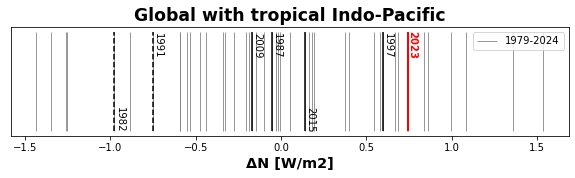

In [27]:
composite_years = [1982, 1987, 1991, 1997,  2015, 2009]
dn_composite = dn_mean.where(dn_mean.year.isin([composite_years]), drop = True)

# Create a figure
fig, ax = plt.subplots(figsize=(10, 2))

# Plot all years in grey
ax.vlines(dn_mean, ymin=0, ymax=1, color='grey', linewidth=0.8, label = '1979-2024')

# Plot composite years in black
ax.vlines(dn_mean.sel(year = 1982), ymin=0, ymax=1, color='black', linewidth=1.5, linestyle = '--')
ax.vlines(dn_mean.sel(year = 1987), ymin=0, ymax=1, color='black', linewidth=1.5)
ax.vlines(dn_mean.sel(year = 1991), ymin=0, ymax=1, color='black', linewidth=1.5, linestyle = '--')
ax.vlines(dn_mean.sel(year = 1997), ymin=0, ymax=1, color='black', linewidth=1.5)
ax.vlines(dn_mean.sel(year = 2009), ymin=0, ymax=1, color='black', linewidth=1.5)
ax.vlines(dn_mean.sel(year = 2015), ymin=0, ymax=1, color='black', linewidth=1.5)





for y in dn_composite.year.values: 
    x = dn_mean.sel(year = y)
    if y in [1991, 1987, 1997, 2009]:
        ax.annotate(y, (x, 0.75), rotation = 270)
    else: 
        ax.annotate(y, (x, 0.), rotation = 270)
        

x = dn_mean.sel(year= 2023)
ax.vlines(x, ymin=0, ymax=1, color='red', linewidth=2)
ax.annotate(2023,  (x, 0.75), rotation = 270, fontweight = 'bold', color = 'r')


# Formatting
#ax.set_xticks(years[::5])  # Show every 5th year for readability
#ax.set_xlim(min(years) - 1, max(years) + 1)
ax.set_yticks([])
ax.set_xlabel("ΔN [W/m2]")
ax.set_title("Global with tropical Indo-Pacific")

plt.legend()


In [83]:
dn_mean

<xarray.DataArray 'tnet' (year: 46)>
array([        nan, -0.25926405,  0.46337765, -0.5007551 , -1.06347303,
        1.49957516,  0.42482063, -0.07794406,  0.05251068, -0.41875696,
        0.74829871, -0.53905072, -0.32344715, -1.74182719,  1.5819826 ,
        0.59128739,  0.25414167, -0.29945801,  0.54759151, -1.09999617,
        1.21324292, -0.19880856, -0.03125987, -0.50268416,  0.6533043 ,
       -0.21566285,  0.21973424,  0.1539265 , -0.57539104,  0.78877096,
        0.0633337 , -1.04732966,  0.71793037,  0.31621936, -0.99557324,
        0.18215938,  0.12775233, -0.2263367 ,  0.28563392,  0.34012627,
       -0.24622882, -0.43860993,  0.61413459, -0.06960913,  0.42792525,
       -1.22583125])
Coordinates:
    number   int64 0
  * year     (year) int64 1979 1980 1981 1982 1983 ... 2020 2021 2022 2023 2024

In [ ]:
dn_mean = dtoa.sel(lat = slice(-20, 20)).weighted(weights).mean(('lat', 'lon'))

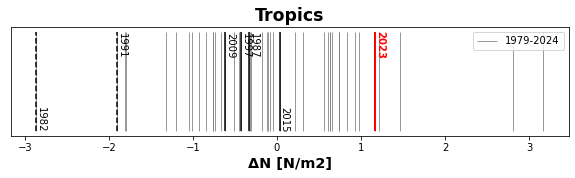

In [ ]:
composite_years = [1982, 1987, 1991, 1997,  2015, 2009]
dn_composite = dn_mean.where(dn_mean.year.isin([composite_years]), drop = True)

# Create a figure
fig, ax = plt.subplots(figsize=(10, 2))

# Plot all years in grey
ax.vlines(dn_mean, ymin=0, ymax=1, color='grey', linewidth=0.8, label = '1979-2024')

# Plot composite years in black
ax.vlines(dn_mean.sel(year = 1982), ymin=0, ymax=1, color='black', linewidth=1.5, linestyle = '--')
ax.vlines(dn_mean.sel(year = 1987), ymin=0, ymax=1, color='black', linewidth=1.5)
ax.vlines(dn_mean.sel(year = 1991), ymin=0, ymax=1, color='black', linewidth=1.5, linestyle = '--')
ax.vlines(dn_mean.sel(year = 1997), ymin=0, ymax=1, color='black', linewidth=1.5)
ax.vlines(dn_mean.sel(year = 2009), ymin=0, ymax=1, color='black', linewidth=1.5)
ax.vlines(dn_mean.sel(year = 2015), ymin=0, ymax=1, color='black', linewidth=1.5)





for y in dn_composite.year.values: 
    x = dn_mean.sel(year = y)
    if y in [1991, 1987, 1997, 2009]:
        ax.annotate(y, (x, 0.75), rotation = 270)
    else: 
        ax.annotate(y, (x, 0.), rotation = 270)
        

x = dn_mean.sel(year= 2023)
ax.vlines(x, ymin=0, ymax=1, color='red', linewidth=2)
ax.annotate(2023,  (x, 0.75), rotation = 270, fontweight = 'bold', color = 'r')


# Formatting
#ax.set_xticks(years[::5])  # Show every 5th year for readability
#ax.set_xlim(min(years) - 1, max(years) + 1)
ax.set_yticks([])
ax.set_xlabel("ΔN [N/m2]")
ax.set_title("Tropics")

plt.legend()


In [ ]:
dn_mean = dtoa.sel(lat = slice(-60, -20)).weighted(weights).mean(('lat', 'lon'))

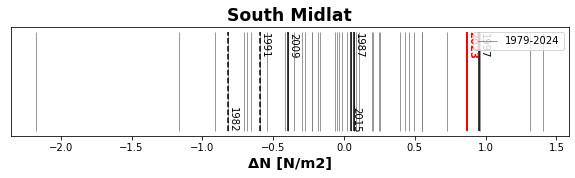

In [ ]:
composite_years = [1982, 1987, 1991, 1997,  2015, 2009]
dn_composite = dn_mean.where(dn_mean.year.isin([composite_years]), drop = True)

# Create a figure
fig, ax = plt.subplots(figsize=(10, 2))

# Plot all years in grey
ax.vlines(dn_mean, ymin=0, ymax=1, color='grey', linewidth=0.8, label = '1979-2024')

# Plot composite years in black
ax.vlines(dn_mean.sel(year = 1982), ymin=0, ymax=1, color='black', linewidth=1.5, linestyle = '--')
ax.vlines(dn_mean.sel(year = 1987), ymin=0, ymax=1, color='black', linewidth=1.5)
ax.vlines(dn_mean.sel(year = 1991), ymin=0, ymax=1, color='black', linewidth=1.5, linestyle = '--')
ax.vlines(dn_mean.sel(year = 1997), ymin=0, ymax=1, color='black', linewidth=1.5)
ax.vlines(dn_mean.sel(year = 2009), ymin=0, ymax=1, color='black', linewidth=1.5)
ax.vlines(dn_mean.sel(year = 2015), ymin=0, ymax=1, color='black', linewidth=1.5)





for y in dn_composite.year.values: 
    x = dn_mean.sel(year = y)
    if y in [1991, 1987, 1997, 2009]:
        ax.annotate(y, (x, 0.75), rotation = 270)
    else: 
        ax.annotate(y, (x, 0.), rotation = 270)
        

x = dn_mean.sel(year= 2023)
ax.vlines(x, ymin=0, ymax=1, color='red', linewidth=2)
ax.annotate(2023,  (x, 0.75), rotation = 270, fontweight = 'bold', color = 'r')


# Formatting
#ax.set_xticks(years[::5])  # Show every 5th year for readability
#ax.set_xlim(min(years) - 1, max(years) + 1)
ax.set_yticks([])
ax.set_xlabel("ΔN [N/m2]")
ax.set_title("South Midlat")

plt.legend()


In [ ]:
dn_mean = dtoa.sel(lat = slice(20, 60)).weighted(weights).mean(('lat', 'lon'))

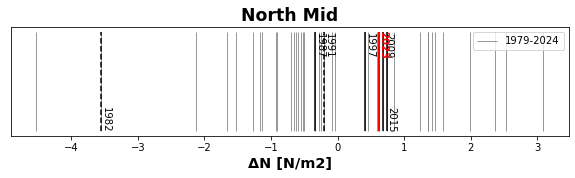

In [ ]:
composite_years = [1982, 1987, 1991, 1997,  2015, 2009]
dn_composite = dn_mean.where(dn_mean.year.isin([composite_years]), drop = True)

# Create a figure
fig, ax = plt.subplots(figsize=(10, 2))

# Plot all years in grey
ax.vlines(dn_mean, ymin=0, ymax=1, color='grey', linewidth=0.8, label = '1979-2024')

# Plot composite years in black
ax.vlines(dn_mean.sel(year = 1982), ymin=0, ymax=1, color='black', linewidth=1.5, linestyle = '--')
ax.vlines(dn_mean.sel(year = 1987), ymin=0, ymax=1, color='black', linewidth=1.5)
ax.vlines(dn_mean.sel(year = 1991), ymin=0, ymax=1, color='black', linewidth=1.5, linestyle = '--')
ax.vlines(dn_mean.sel(year = 1997), ymin=0, ymax=1, color='black', linewidth=1.5)
ax.vlines(dn_mean.sel(year = 2009), ymin=0, ymax=1, color='black', linewidth=1.5)
ax.vlines(dn_mean.sel(year = 2015), ymin=0, ymax=1, color='black', linewidth=1.5)





for y in dn_composite.year.values: 
    x = dn_mean.sel(year = y)
    if y in [1991, 1987, 1997, 2009]:
        ax.annotate(y, (x, 0.75), rotation = 270)
    else: 
        ax.annotate(y, (x, 0.), rotation = 270)
        

x = dn_mean.sel(year= 2023)
ax.vlines(x, ymin=0, ymax=1, color='red', linewidth=2)
ax.annotate(2023,  (x, 0.75), rotation = 270, fontweight = 'bold', color = 'r')


# Formatting
#ax.set_xticks(years[::5])  # Show every 5th year for readability
#ax.set_xlim(min(years) - 1, max(years) + 1)
ax.set_yticks([])
ax.set_xlabel("ΔN [N/m2]")
ax.set_title("North Mid")

plt.legend()


In [ ]:
#ALL

In [ ]:
#compute fractional area for each band
w_npol = weights.sel(lat = slice(60, 90)).sum()/ weights.sum()
w_nmidlat = weights.sel(lat = slice(20, 60)).sum()/ weights.sum()
w_trop = weights.sel(lat = slice(-20, 20)).sum()/ weights.sum()
w_smidlat = weights.sel(lat = slice(-60, -20)).sum()/ weights.sum()
w_spol = weights.sel(lat = slice(-90, -60)).sum()/ weights.sum()


# extract latitudinal bands
dn_npol = dtoa.sel(lat = slice(60, 90)).weighted(weights).mean(('lat', 'lon'))* w_npol
dn_nmidlat = dtoa.sel(lat = slice(20, 60)).weighted(weights).mean(('lat', 'lon'))* w_nmidlat
dn_trop = dtoa.sel(lat = slice(-20, 20)).weighted(weights).mean(('lat', 'lon'))* w_trop
dn_smidlat = dtoa.sel(lat = slice(-60, -20)).weighted(weights).mean(('lat', 'lon'))* w_smidlat
dn_spol = dtoa.sel(lat = slice(-90, -60)).weighted(weights).mean(('lat', 'lon'))* w_spol


ls = [dn_npol, dn_nmidlat, dn_trop, dn_smidlat, dn_spol]

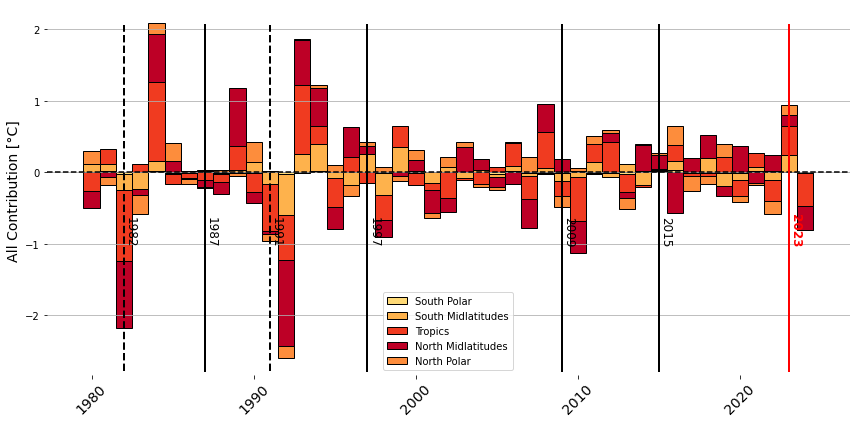

In [ ]:
# make the plot
fig, ax = plt.subplots(1,1, figsize = (12,6))

ls = [dn_npol, dn_nmidlat, dn_trop, dn_smidlat, dn_spol][::-1]

labels = ['North Polar', 'North Midlatitudes', 'Tropics', 'South Midlatitudes', 'South Polar'][::-1]

colors = ['#fd8d3c',  '#bd0026', '#f03b20', '#feb24c', '#fed976'][::-1]


years_of_interest = [1982, 1987, 1991, 1997, 2009, 2015, 2023]


bottom_pos = np.zeros(len(ls[0]['year']))
bottom_neg = np.zeros(len(ls[0]['year']))

for i, r in enumerate(ls):
    values = r.values
    bottom = np.where(values>=0, bottom_pos, bottom_neg)
    ax.bar(r['year'].values, values, width=1,
           bottom=bottom, label=labels[i], color = colors[i], edgecolor = 'k')
    bottom_pos += np.where(values >= 0, values, 0)
    bottom_neg += np.where(values < 0, values, 0)

    
# Add a dashed line centered on zero
ax.axhline(0, color='black', linestyle='--')

#ax.scatter(sst.year.values, sst.anom.values, color = 'k', zorder = 20, s = 5)


# Add legend, labels, and title
ax.legend()
ax.set_ylabel('SST Anomaly Contributions [K]\n(1991-2020)')
ax.set_title('')
plt.xticks(rotation=45, fontweight = 'normal', size = 14)



# Only display horizontal grid lines and remove the plot frame
ax.yaxis.grid(True)  # Horizontal grid lines
ax.xaxis.grid(False)  # No vertical grid lines


ax.set_ylabel('All Contribution [°C]', fontsize = 14, fontweight = 'normal')

for year in years_of_interest:
    if year == 2023:
        ax.annotate(str(year), (year, -1), rotation = 270, fontsize = 12, fontweight = 'bold', color = 'r')
    else:
        ax.annotate(str(year), (year, -1), rotation = 270, fontsize = 12)
    # Define rectangle parameters: (x, y) for bottom left corner, width, height
    if year in [1982, 1991]:
        ax.axvline(year, ymin = .01, ymax = .95, linestyle='--', color='k', linewidth=2)
    elif year == 2023:
        ax.axvline(year, ymin = .01, ymax = .95, linestyle='-', color='r', linewidth=2)
    else:
        ax.axvline(year, ymin = .01, ymax = .95, linestyle='-', color='k', linewidth=2)
    

for a in [ax]:
    a.spines['top'].set_visible(False)
    a.spines['right'].set_visible(False)
    a.spines['left'].set_visible(False)
    a.spines['bottom'].set_visible(False)

fig.tight_layout()

plt.show()


    


In [ ]:
l = [l.sel(year = 2023).values for l in ls]
print(l)
print(sum(l))

[array(0.00659285), array(0.2298335), array(0.40339418), array(0.16269139), array(0.14384948)]
0.9463614058761889


In [ ]:
0.177/0.74

0.2391891891891892

In [ ]:
land_mask = masks.seamask ==0
land_surface = land_mask.weighted(weights).sum()

land_fraction  = land_surface / (land_surface + ocean_surface)

NameError: name 'land_surface' is not defined

In [35]:
land_fraction

NameError: name 'land_fraction' is not defined

In [ ]:

#make maks
npol_land = (masks.seamask ==0).where(masks.lat >=60)
nmidlat_land = (masks.seamask ==0).where((masks.lat <60) & (masks.lat >=20))
tropics_land = (masks.seamask ==0).where((masks.lat <20) & (masks.lat >=-20))
smidlat_land = (masks.seamask ==0).where((masks.lat < -20) & (masks.lat >=-60))
spol_land = (masks.seamask ==0).where(masks.lat <= -60)



#compute fractional area for each band
w_npol = npol_land.weighted(weights).sum()/ land_surface * land_fraction
w_nmidlat = nmidlat_land.weighted(weights).sum()/ land_surface * land_fraction
w_trop = tropics_land.weighted(weights).sum()/ land_surface * land_fraction
w_smidlat = smidlat_land.weighted(weights).sum()/ land_surface * land_fraction
w_spol = spol_land.weighted(weights).sum()/ land_surface * land_fraction



# extract latitudinal bands
dn_npol = dtoa.where(npol_land).weighted(weights).mean(('lat', 'lon'))* w_npol
dn_nmidlat = dtoa.where(nmidlat_land).weighted(weights).mean(('lat', 'lon'))* w_nmidlat
dn_trop = dtoa.where(tropics_land).weighted(weights).mean(('lat', 'lon'))* w_trop
dn_smidlat = dtoa.where(smidlat_land).weighted(weights).mean(('lat', 'lon'))* w_smidlat
dn_spol = dtoa.where(spol_land).weighted(weights).mean(('lat', 'lon'))* w_spol



NameError: name 'land_fraction' is not defined

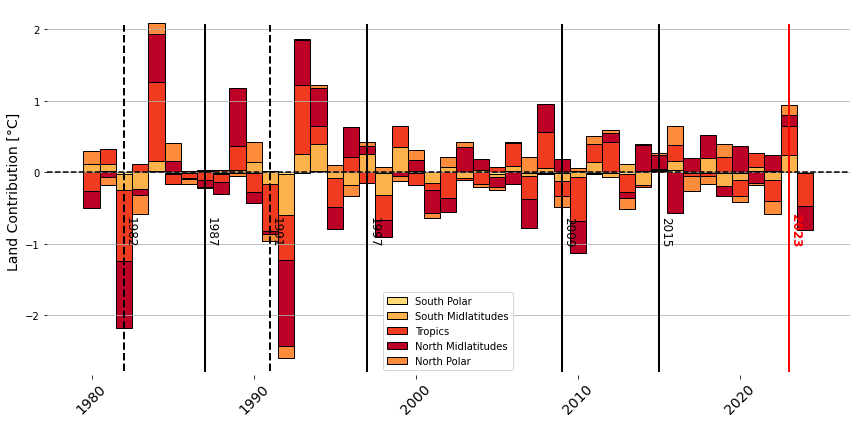

In [37]:
# make the plot
fig, ax = plt.subplots(1,1, figsize = (12,6))

ls = [dn_npol, dn_nmidlat, dn_trop, dn_smidlat, dn_spol][::-1]

labels = ['North Polar', 'North Midlatitudes', 'Tropics', 'South Midlatitudes', 'South Polar'][::-1]

colors = ['#fd8d3c',  '#bd0026', '#f03b20', '#feb24c', '#fed976'][::-1]


years_of_interest = [1982, 1987, 1991, 1997, 2009, 2015, 2023]


bottom_pos = np.zeros(len(ls[0]['year']))
bottom_neg = np.zeros(len(ls[0]['year']))

for i, r in enumerate(ls):
    values = r.values
    bottom = np.where(values>=0, bottom_pos, bottom_neg)
    ax.bar(r['year'].values, values, width=1,
           bottom=bottom, label=labels[i], color = colors[i], edgecolor = 'k')
    bottom_pos += np.where(values >= 0, values, 0)
    bottom_neg += np.where(values < 0, values, 0)

    
# Add a dashed line centered on zero
ax.axhline(0, color='black', linestyle='--')

#ax.scatter(sst.year.values, sst.anom.values, color = 'k', zorder = 20, s = 5)


# Add legend, labels, and title
ax.legend()
ax.set_ylabel('SST Anomaly Contributions [K]\n(1991-2020)')
ax.set_title('')
plt.xticks(rotation=45, fontweight = 'normal', size = 14)



# Only display horizontal grid lines and remove the plot frame
ax.yaxis.grid(True)  # Horizontal grid lines
ax.xaxis.grid(False)  # No vertical grid lines


ax.set_ylabel('Land Contribution [°C]', fontsize = 14, fontweight = 'normal')

for year in years_of_interest:
    if year == 2023:
        ax.annotate(str(year), (year, -1), rotation = 270, fontsize = 12, fontweight = 'bold', color = 'r')
    else:
        ax.annotate(str(year), (year, -1), rotation = 270, fontsize = 12)
    # Define rectangle parameters: (x, y) for bottom left corner, width, height
    if year in [1982, 1991]:
        ax.axvline(year, ymin = .01, ymax = .95, linestyle='--', color='k', linewidth=2)
    elif year == 2023:
        ax.axvline(year, ymin = .01, ymax = .95, linestyle='-', color='r', linewidth=2)
    else:
        ax.axvline(year, ymin = .01, ymax = .95, linestyle='-', color='k', linewidth=2)
    

for a in [ax]:
    a.spines['top'].set_visible(False)
    a.spines['right'].set_visible(False)
    a.spines['left'].set_visible(False)
    a.spines['bottom'].set_visible(False)

fig.tight_layout()

plt.show()


    


In [38]:
l = [l.sel(year = 2023).values for l in ls]
print(l)
print(sum(l))

[array(0.00659285), array(0.2298335), array(0.40339418), array(0.16269139), array(0.14384948)]
0.9463614058761889


In [39]:
ocean_fraction = ocean_surface / (land_surface + ocean_surface)

NameError: name 'ocean_surface' is not defined

In [40]:

#make maks
npol_ocean = (masks.seamask ==1).where(masks.lat >=60)
nmidlat_ocean = (masks.seamask ==1).where((masks.lat <60) & (masks.lat >=20))
tropics_ocean = (masks.seamask ==1).where((masks.lat <20) & (masks.lat >=-20))
smidlat_ocean = (masks.seamask ==1).where((masks.lat < -20) & (masks.lat >=-60))
spol_ocean = (masks.seamask ==1).where(masks.lat <= -60)

ocean_mask = masks.seamask ==1
ocean_surface = ocean_mask.weighted(weights).sum()


#compute fractional area for each band
w_npol = npol_ocean.weighted(weights).sum()/ ocean_surface * ocean_fraction
w_nmidlat = nmidlat_ocean.weighted(weights).sum()/ ocean_surface * ocean_fraction
w_trop = tropics_ocean.weighted(weights).sum()/ ocean_surface * ocean_fraction
w_smidlat = smidlat_ocean.weighted(weights).sum()/ ocean_surface * ocean_fraction
w_spol = spol_ocean.weighted(weights).sum()/ ocean_surface * ocean_fraction



# extract latitudinal bands
dn_npol = dtoa.where(npol_ocean).weighted(weights).mean(('lat', 'lon'))* w_npol
dn_nmidlat = dtoa.where(nmidlat_ocean).weighted(weights).mean(('lat', 'lon'))* w_nmidlat
dn_trop = dtoa.where(tropics_ocean).weighted(weights).mean(('lat', 'lon'))* w_trop
dn_smidlat = dtoa.where(smidlat_ocean).weighted(weights).mean(('lat', 'lon'))* w_smidlat
dn_spol = dtoa.where(spol_ocean).weighted(weights).mean(('lat', 'lon'))* w_spol



NameError: name 'ocean_fraction' is not defined

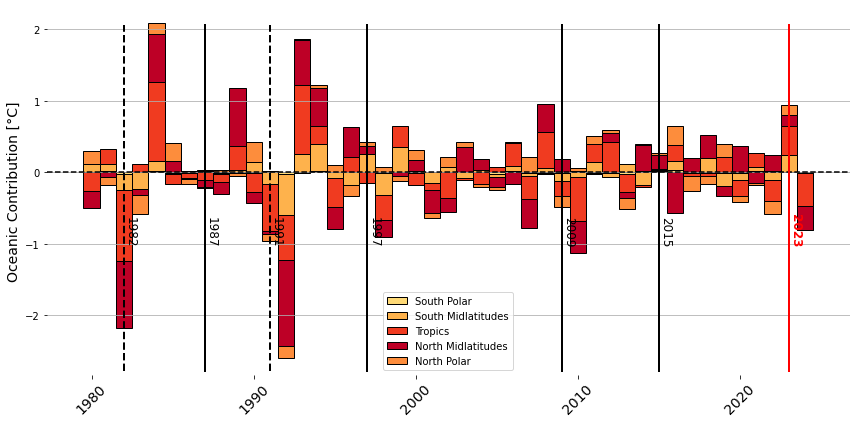

In [41]:
# make the plot
fig, ax = plt.subplots(1,1, figsize = (12,6))

ls = [dn_npol, dn_nmidlat, dn_trop, dn_smidlat, dn_spol][::-1]

labels = ['North Polar', 'North Midlatitudes', 'Tropics', 'South Midlatitudes', 'South Polar'][::-1]

colors = ['#fd8d3c',  '#bd0026', '#f03b20', '#feb24c', '#fed976'][::-1]


years_of_interest = [1982, 1987, 1991, 1997, 2009, 2015, 2023]


bottom_pos = np.zeros(len(ls[0]['year']))
bottom_neg = np.zeros(len(ls[0]['year']))

for i, r in enumerate(ls):
    values = r.values
    bottom = np.where(values>=0, bottom_pos, bottom_neg)
    ax.bar(r['year'].values, values, width=1,
           bottom=bottom, label=labels[i], color = colors[i], edgecolor = 'k')
    bottom_pos += np.where(values >= 0, values, 0)
    bottom_neg += np.where(values < 0, values, 0)

    
# Add a dashed line centered on zero
ax.axhline(0, color='black', linestyle='--')

#ax.scatter(sst.year.values, sst.anom.values, color = 'k', zorder = 20, s = 5)


# Add legend, labels, and title
ax.legend()
ax.set_ylabel('SST Anomaly Contributions [K]\n(1991-2020)')
ax.set_title('')
plt.xticks(rotation=45, fontweight = 'normal', size = 14)



# Only display horizontal grid lines and remove the plot frame
ax.yaxis.grid(True)  # Horizontal grid lines
ax.xaxis.grid(False)  # No vertical grid lines


ax.set_ylabel('Oceanic Contribution [°C]', fontsize = 14, fontweight = 'normal')

for year in years_of_interest:
    if year == 2023:
        ax.annotate(str(year), (year, -1), rotation = 270, fontsize = 12, fontweight = 'bold', color = 'r')
    else:
        ax.annotate(str(year), (year, -1), rotation = 270, fontsize = 12)
    # Define rectangle parameters: (x, y) for bottom left corner, width, height
    if year in [1982, 1991]:
        ax.axvline(year, ymin = .01, ymax = .95, linestyle='--', color='k', linewidth=2)
    elif year == 2023:
        ax.axvline(year, ymin = .01, ymax = .95, linestyle='-', color='r', linewidth=2)
    else:
        ax.axvline(year, ymin = .01, ymax = .95, linestyle='-', color='k', linewidth=2)
    

for a in [ax]:
    a.spines['top'].set_visible(False)
    a.spines['right'].set_visible(False)
    a.spines['left'].set_visible(False)
    a.spines['bottom'].set_visible(False)

fig.tight_layout()

plt.show()


    


In [124]:
l = [l.sel(year = 2023).values for l in ls]
print(l)
print(sum(l))

[array(0.03106441), array(0.18042891), array(0.17744284), array(0.09323824), array(0.02232001)]
0.5044944154138524


In [126]:
0.177/0.50

0.354

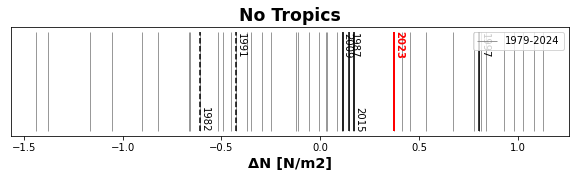

In [ ]:
composite_years = [1982, 1987, 1991, 1997,  2015, 2009]
dn_composite = dn_mean.where(dn_mean.year.isin([composite_years]), drop = True)

# Create a figure
fig, ax = plt.subplots(figsize=(10, 2))

# Plot all years in grey
ax.vlines(dn_mean, ymin=0, ymax=1, color='grey', linewidth=0.8, label = '1979-2024')

# Plot composite years in black
ax.vlines(dn_mean.sel(year = 1982), ymin=0, ymax=1, color='black', linewidth=1.5, linestyle = '--')
ax.vlines(dn_mean.sel(year = 1987), ymin=0, ymax=1, color='black', linewidth=1.5)
ax.vlines(dn_mean.sel(year = 1991), ymin=0, ymax=1, color='black', linewidth=1.5, linestyle = '--')
ax.vlines(dn_mean.sel(year = 1997), ymin=0, ymax=1, color='black', linewidth=1.5)
ax.vlines(dn_mean.sel(year = 2009), ymin=0, ymax=1, color='black', linewidth=1.5)
ax.vlines(dn_mean.sel(year = 2015), ymin=0, ymax=1, color='black', linewidth=1.5)





for y in dn_composite.year.values: 
    x = dn_mean.sel(year = y)
    if y in [1991, 1987, 1997, 2009]:
        ax.annotate(y, (x, 0.75), rotation = 270)
    else: 
        ax.annotate(y, (x, 0.), rotation = 270)
        

x = dn_mean.sel(year= 2023)
ax.vlines(x, ymin=0, ymax=1, color='red', linewidth=2)
ax.annotate(2023,  (x, 0.75), rotation = 270, fontweight = 'bold', color = 'r')


# Formatting
#ax.set_xticks(years[::5])  # Show every 5th year for readability
#ax.set_xlim(min(years) - 1, max(years) + 1)
ax.set_yticks([])
ax.set_xlabel("ΔN [N/m2]")
ax.set_title("No Tropics")

plt.legend()


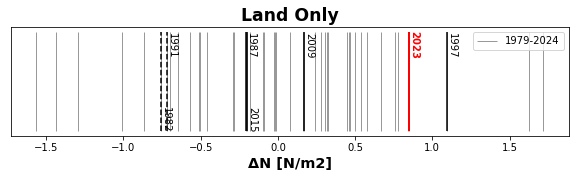

In [ ]:
composite_years = [1982, 1987, 1991, 1997,  2015, 2009]
dn_composite = dn_mean.where(dn_mean.year.isin([composite_years]), drop = True)

# Create a figure
fig, ax = plt.subplots(figsize=(10, 2))

# Plot all years in grey
ax.vlines(dn_mean, ymin=0, ymax=1, color='grey', linewidth=0.8, label = '1979-2024')

# Plot composite years in black
ax.vlines(dn_mean.sel(year = 1982), ymin=0, ymax=1, color='black', linewidth=1.5, linestyle = '--')
ax.vlines(dn_mean.sel(year = 1987), ymin=0, ymax=1, color='black', linewidth=1.5)
ax.vlines(dn_mean.sel(year = 1991), ymin=0, ymax=1, color='black', linewidth=1.5, linestyle = '--')
ax.vlines(dn_mean.sel(year = 1997), ymin=0, ymax=1, color='black', linewidth=1.5)
ax.vlines(dn_mean.sel(year = 2009), ymin=0, ymax=1, color='black', linewidth=1.5)
ax.vlines(dn_mean.sel(year = 2015), ymin=0, ymax=1, color='black', linewidth=1.5)





for y in dn_composite.year.values: 
    x = dn_mean.sel(year = y)
    if y in [1991, 1987, 1997, 2009]:
        ax.annotate(y, (x, 0.75), rotation = 270)
    else: 
        ax.annotate(y, (x, 0.), rotation = 270)
        

x = dn_mean.sel(year= 2023)
ax.vlines(x, ymin=0, ymax=1, color='red', linewidth=2)
ax.annotate(2023,  (x, 0.75), rotation = 270, fontweight = 'bold', color = 'r')


# Formatting
#ax.set_xticks(years[::5])  # Show every 5th year for readability
#ax.set_xlim(min(years) - 1, max(years) + 1)
ax.set_yticks([])
ax.set_xlabel("ΔN [N/m2]")
ax.set_title("Land Only")

plt.legend()


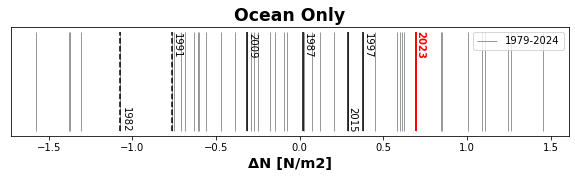

In [ ]:
composite_years = [1982, 1987, 1991, 1997,  2015, 2009]
dn_composite = dn_mean.where(dn_mean.year.isin([composite_years]), drop = True)

# Create a figure
fig, ax = plt.subplots(figsize=(10, 2))

# Plot all years in grey
ax.vlines(dn_mean, ymin=0, ymax=1, color='grey', linewidth=0.8, label = '1979-2024')

# Plot composite years in black
ax.vlines(dn_mean.sel(year = 1982), ymin=0, ymax=1, color='black', linewidth=1.5, linestyle = '--')
ax.vlines(dn_mean.sel(year = 1987), ymin=0, ymax=1, color='black', linewidth=1.5)
ax.vlines(dn_mean.sel(year = 1991), ymin=0, ymax=1, color='black', linewidth=1.5, linestyle = '--')
ax.vlines(dn_mean.sel(year = 1997), ymin=0, ymax=1, color='black', linewidth=1.5)
ax.vlines(dn_mean.sel(year = 2009), ymin=0, ymax=1, color='black', linewidth=1.5)
ax.vlines(dn_mean.sel(year = 2015), ymin=0, ymax=1, color='black', linewidth=1.5)





for y in dn_composite.year.values: 
    x = dn_mean.sel(year = y)
    if y in [1991, 1987, 1997, 2009]:
        ax.annotate(y, (x, 0.75), rotation = 270)
    else: 
        ax.annotate(y, (x, 0.), rotation = 270)
        

x = dn_mean.sel(year= 2023)
ax.vlines(x, ymin=0, ymax=1, color='red', linewidth=2)
ax.annotate(2023,  (x, 0.75), rotation = 270, fontweight = 'bold', color = 'r')


# Formatting
#ax.set_xticks(years[::5])  # Show every 5th year for readability
#ax.set_xlim(min(years) - 1, max(years) + 1)
ax.set_yticks([])
ax.set_xlabel("ΔN [N/m2]")
ax.set_title("Ocean Only")

plt.legend()


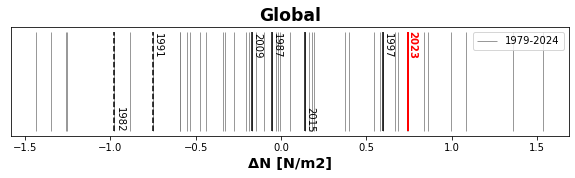

In [15]:
composite_years = [1982, 1987, 1991, 1997,  2015, 2009]
dn_composite = dn_mean.where(dn_mean.year.isin([composite_years]), drop = True)

# Create a figure
fig, ax = plt.subplots(figsize=(10, 2))

# Plot all years in grey
ax.vlines(dn_mean, ymin=0, ymax=1, color='grey', linewidth=0.8, label = '1979-2024')

# Plot composite years in black
ax.vlines(dn_mean.sel(year = 1982), ymin=0, ymax=1, color='black', linewidth=1.5, linestyle = '--')
ax.vlines(dn_mean.sel(year = 1987), ymin=0, ymax=1, color='black', linewidth=1.5)
ax.vlines(dn_mean.sel(year = 1991), ymin=0, ymax=1, color='black', linewidth=1.5, linestyle = '--')
ax.vlines(dn_mean.sel(year = 1997), ymin=0, ymax=1, color='black', linewidth=1.5)
ax.vlines(dn_mean.sel(year = 2009), ymin=0, ymax=1, color='black', linewidth=1.5)
ax.vlines(dn_mean.sel(year = 2015), ymin=0, ymax=1, color='black', linewidth=1.5)





for y in dn_composite.year.values: 
    x = dn_mean.sel(year = y)
    if y in [1991, 1987, 1997, 2009]:
        ax.annotate(y, (x, 0.75), rotation = 270)
    else: 
        ax.annotate(y, (x, 0.), rotation = 270)
        

x = dn_mean.sel(year= 2023)
ax.vlines(x, ymin=0, ymax=1, color='red', linewidth=2)
ax.annotate(2023,  (x, 0.75), rotation = 270, fontweight = 'bold', color = 'r')


# Formatting
#ax.set_xticks(years[::5])  # Show every 5th year for readability
#ax.set_xlim(min(years) - 1, max(years) + 1)
ax.set_yticks([])
ax.set_xlabel("ΔN [N/m2]")
ax.set_title("Global")

plt.legend()


In [129]:
trop_indopac = masks.open_ocean.isin([2,3]).where(masks.lat >= -20).where(masks.lat <=20)
w = trop_indopac.weighted(weights).sum()/ masks.seamask.isin([0,1]).weighted(weights).sum()
trop_indopac = dtoa.where(trop_indopac).weighted(weights).mean(('lat', 'lon'))* w

In [131]:
global_mean = dtoa.weighted(weights).mean(('lat', 'lon'))

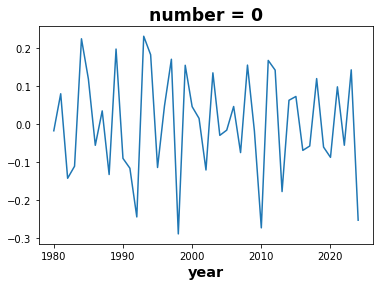

In [136]:
trop_indopac.plot()

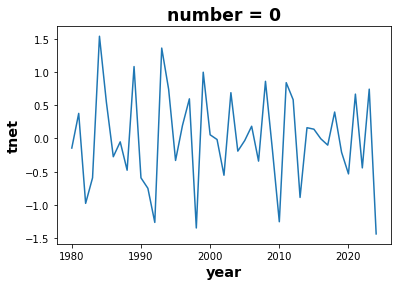

In [137]:
global_mean.plot()